In [2]:
# Import data as dataframes
import json
from pathlib import Path
import pandas as pd

# Importing data
def import_data(file_name):
    with open(Path.cwd().parents[1] / "data" / "gold" / file_name, "r", encoding="utf-8") as f:
        data = json.load(f)
    return pd.DataFrame(data)

members_df = import_data("members_119.json")
votes_df = import_data("votes_119.json")
bills_df = import_data("bills_119.json")

vote_party_totals_df = import_data("vote_party_totals_119.json")

# vote_party_totals_df.head()
# votes_df.head()


In [3]:
# votes_bills_df = votes_df.merge(bills_df, on='bill_id', how='left')

bill_cols = ['bill_id', 'bill_type', 'bill_num', 'title', 'policy_area']  # whichever columns you want
votes_bills_df = votes_df.merge(bills_df[bill_cols], on='bill_id', how='left')

# votes_bills_df.head()

In [4]:
vote_party_totals_df = vote_party_totals_df.merge(votes_bills_df, on='vote_id', how='left')

# vote_party_totals_df.head(10)

In [11]:
import pandas as pd

# --- Step 1: Filter to only D and R rows ---
dr_df = vote_party_totals_df[vote_party_totals_df['party'].isin(['D', 'R'])].copy()

# --- Filter by question keywords & exclude procedural bills ---
PASSAGE_KEYWORDS = [
    "Passage", "Pass", "Agreeing to the Resolution",
    "Joint Resolution", "Concurrent Resolution",
    "Concur in the Senate Amendment"
]

keyword_mask = dr_df['question'].str.contains(
    '|'.join(PASSAGE_KEYWORDS), case=False, na=False
)

procedural_mask = ~(
    (dr_df['bill_type'] == 'HRES') &
    dr_df['title'].str.contains('providing for consideration', case=False, na=False)
)

dr_df = dr_df[keyword_mask & procedural_mask].copy()

# --- Step 2: Calculate each party's "yes rate" per vote ---
dr_df['total'] = dr_df['yes_count'] + dr_df['no_count']
dr_df['yes_rate'] = dr_df['yes_count'] / dr_df['total'].replace(0, pd.NA)

# Pivot so each row = one vote, columns = D and R yes rates
pivot = dr_df.pivot_table(
    index=['vote_id', 'bill_id', 'title', 'policy_area'],
    columns='party',
    values='yes_rate'
).reset_index()

pivot.columns.name = None
pivot = pivot.rename(columns={
    # 'bill_id_x': 'bill_id',
    # 'title_y': 'title',
    # 'policy_area_y': 'policy_area',
    # 'question_x': 'question',
    'D': 'D_yes_rate',
    'R': 'R_yes_rate'
})

# --- Step 3: Calculate partisan score ---
# Cast to float64 to avoid issues with pd.NA mixing types
pivot['D_yes_rate'] = pivot['D_yes_rate'].astype(float)
pivot['R_yes_rate'] = pivot['R_yes_rate'].astype(float)

# Score = absolute difference in yes rates (0 = unanimous, 1 = completely split)
pivot['partisan_score'] = (pivot['D_yes_rate'] - pivot['R_yes_rate']).abs().round(3)

# --- Step 4: Determine which party was in favor ---
# "In favor" = yes_rate > 0.5 for that party
def party_in_favor(row):
    d = row['D_yes_rate']
    r = row['R_yes_rate']
    if pd.isna(d) or pd.isna(r):
        return None
    d_favor = d > 0.5
    r_favor = r > 0.5
    if d_favor and not r_favor:
        return 'D'
    elif r_favor and not d_favor:
        return 'R'
    elif d_favor and r_favor:
        return 'Both'
    else:
        return 'Neither'

pivot['party_in_favor'] = pivot.apply(party_in_favor, axis=1)

# --- Step 5: Final output ---
partisan_df = pivot[[
    'vote_id', 
    'bill_id', 'title', 
    'policy_area',
    'D_yes_rate', 'R_yes_rate', 
    'partisan_score', 'party_in_favor'
]].sort_values('partisan_score', ascending=False).reset_index(drop=True)

partisan_df.head(5)


,vote_id,bill_id,title,policy_area,D_yes_rate,R_yes_rate,partisan_score,party_in_favor
0,roll_S00097_119_1,HJRES35_119,Providing for congressional disapproval under ...,Environmental Protection,0.0,1.0,1.0,R
1,roll_S00281_119_1,HJRES89_119,Providing congressional disapproval under chap...,Environmental Protection,0.0,1.0,1.0,R
2,roll_S00037_119_2,HJRES142_119,Disapproving the action of the District of Col...,Government Operations and Politics,0.0,1.0,1.0,R
3,roll_H00095_119_1,SJRES28_119,A joint resolution disapproving the rule submi...,Finance and Financial Sector,0.0,1.0,1.0,R
4,roll_S00162_119_1,HJRES24_119,Providing for congressional disapproval under ...,Energy,0.0,1.0,1.0,R


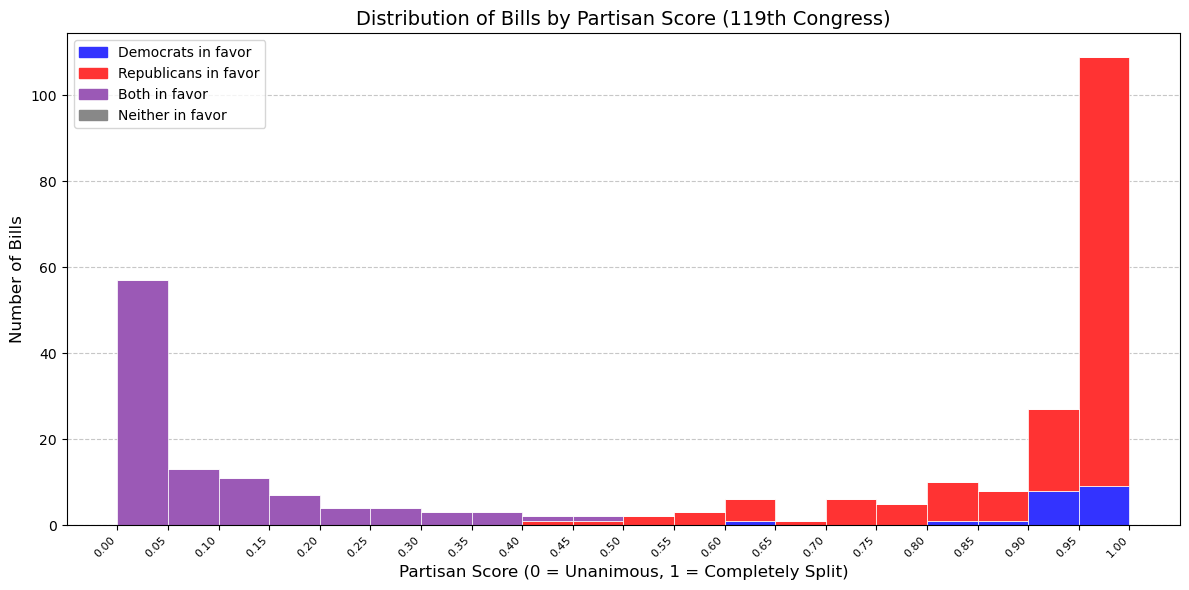

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

color_map = {
    'D':       '#3333FF',
    'R':       '#FF3333',
    'Both':    '#9B59B6',
    'Neither': '#888888'
}

fig, ax = plt.subplots(figsize=(12, 6))

bins = np.arange(0, 1.05, 0.05)

# Plot each party_in_favor group as a stacked histogram
groups = ['D', 'R', 'Both', 'Neither']
data_by_group = [
    partisan_df[partisan_df['party_in_favor'] == g]['partisan_score'].dropna()
    for g in groups
]

ax.hist(
    data_by_group,
    bins=bins,
    stacked=True,
    color=[color_map[g] for g in groups],
    edgecolor='white',
    linewidth=0.5
)

# Labels & formatting
ax.set_xlabel('Partisan Score (0 = Unanimous, 1 = Completely Split)', fontsize=12)
ax.set_ylabel('Number of Bills', fontsize=12)
ax.set_title('Distribution of Bills by Partisan Score (119th Congress)', fontsize=14)
ax.set_xticks(bins)
ax.set_xticklabels([f'{b:.2f}' for b in bins], rotation=45, ha='right', fontsize=8)

# Legend
legend_patches = [
    mpatches.Patch(color=color_map[g], label={
        'D': 'Democrats in favor',
        'R': 'Republicans in favor',
        'Both': 'Both in favor',
        'Neither': 'Neither in favor'
    }[g])
    for g in groups
]
ax.legend(handles=legend_patches, fontsize=10)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()